In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


f = r'/content/junction_data_race_course (1).csv'

df = pd.read_csv(f)
df

,Time,FP_A_Count,FP_A_QueuePct,FP_A_Speed,FP_B_Count,FP_B_QueuePct,FP_B_Speed,FP_C_Count,FP_C_QueuePct,FP_C_Speed,...,District_Office_Speed,Anand_Rao_Jnc_Count,Anand_Rao_Jnc_QueuePct,Anand_Rao_Jnc_Speed,Race_Course_Jnc_Count,Race_Course_Jnc_QueuePct,Race_Course_Jnc_Speed,Palace_Road_Jnc_Count,Palace_Road_Jnc_QueuePct,Palace_Road_Jnc_Speed
0,0,0,0.00,0.00,0,0.00,0.00,0,0.0,0.0,...,0.00,1,0.02,0.00,0,0.0,0.0,0,0.00,0.00
1,1,0,0.00,0.00,0,0.00,0.00,0,0.0,0.0,...,0.00,1,0.02,0.94,0,0.0,0.0,0,0.00,0.00
2,2,0,0.00,0.00,0,0.00,0.00,0,0.0,0.0,...,0.00,1,0.02,1.84,0,0.0,0.0,0,0.00,0.00
3,3,0,0.00,0.00,0,0.00,0.00,0,0.0,0.0,...,0.00,1,0.02,3.02,0,0.0,0.0,1,0.53,0.00
4,4,0,0.00,0.00,0,0.00,0.00,0,0.0,0.0,...,0.00,2,0.03,1.91,0,0.0,0.0,1,0.06,2.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86395,86395,1,0.09,9.99,0,0.08,0.00,0,0.0,0.0,...,11.68,0,0.01,0.00,0,0.0,0.0,1,0.05,4.63
86396,86396,0,0.09,0.00,0,0.08,0.00,0,0.0,0.0,...,0.00,1,0.01,17.38,0,0.0,0.0,2,0.14,10.65
86397,86397,0,0.09,0.00,1,0.08,18.98,0,0.0,0.0,...,0.00,1,0.01,13.67,0,0.0,0.0,2,0.23,8.77
86398,86398,1,0.09,19.84,1,0.08,19.81,0,0.0,0.0,...,0.00,1,0.01,9.67,0,0.0,0.0,2,0.76,6.85


In [ ]:
# Shift predictors to align with target at t+1
xd = df['FP_D_Count']
xa = df['FP_A_Count'][:-1]  # predictors at time t
xc = df['FP_C_Count'][:-1]
xd = xd[1:]            # target at time t+1

granger_df = pd.DataFrame({
    'FP_D_Count': xd.values,  # target
    'FP_A_Count': xa.values,       # predictor 1
    'FP_C_Count': xc.values        # predictor 2
})

granger_df

,FP_D_Count,FP_A_Count,FP_C_Count
0,0,0,0
1,0,0,0
2,0,0,0
3,0,0,0
4,0,0,0
...,...,...,...
86394,0,1,0
86395,0,1,0
86396,0,0,0
86397,1,0,0


In [ ]:
from statsmodels.tsa.stattools import grangercausalitytests

# Test if FP_A and FP_C jointly Granger-cause FP_D
grangercausalitytests(granger_df[['FP_D_Count', 'FP_A_Count']], maxlag=5)
grangercausalitytests(granger_df[['FP_D_Count', 'FP_C_Count']], maxlag=5)



Granger Causality
number of lags (no zero) 1
ssr based F test:         F=295.9330, p=0.0000  , df_denom=86395, df_num=1
ssr based chi2 test:   chi2=295.9433, p=0.0000  , df=1
likelihood ratio test: chi2=295.4376, p=0.0000  , df=1
parameter F test:         F=295.9330, p=0.0000  , df_denom=86395, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=209.7985, p=0.0000  , df_denom=86392, df_num=2
ssr based chi2 test:   chi2=419.6213, p=0.0000  , df=2
likelihood ratio test: chi2=418.6056, p=0.0000  , df=2
parameter F test:         F=209.7985, p=0.0000  , df_denom=86392, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=217.0022, p=0.0000  , df_denom=86389, df_num=3
ssr based chi2 test:   chi2=651.0594, p=0.0000  , df=3
likelihood ratio test: chi2=648.6186, p=0.0000  , df=3
parameter F test:         F=217.0022, p=0.0000  , df_denom=86389, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=165.2546

{np.int64(1): ({'ssr_ftest': (np.float64(314.5119397992166),
    np.float64(3.027956029818981e-70),
    np.float64(86395.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(314.52286098469483),
    np.float64(2.2592925829330764e-70),
    np.int64(1)),
   'lrtest': (np.float64(313.9517528548022),
    np.float64(3.008702252424357e-70),
    np.int64(1)),
   'params_ftest': (np.float64(314.51193979979837),
    np.float64(3.027956028940742e-70),
    np.float64(86395.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(198.62468108084397),
    np.float64(8.632091771856696e-87),
    np.float64(86392.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(397.27235325821084),
    np.float64(5.41258318019861e-87),
    np.int64(2)),
   'lrtest': (np.float64(396.36177086198586),
    np.float64(8.533654164295769e-87),
    np.int64(2)),
   'params_ftest': (np.float64(198.62468108135337),
    np.float64(8.632091767448938e-87),
    np.float64(86392.0),
    2.0)},
   array

In [ ]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series):
    result = adfuller(series)
    print(f"ADF Statistic: {result[0]}")
    print(f"p-value: {result[1]}")

adf_test(granger_df.iloc[:,0])
adf_test(granger_df.iloc[:,1])
adf_test(granger_df.iloc[:,2])

ADF Statistic: -17.001305103713857
p-value: 8.724706607647005e-30
ADF Statistic: -19.189663963172723
p-value: 0.0
ADF Statistic: -21.91322727944427
p-value: 0.0


In [ ]:
from statsmodels.tsa.api import VAR
import pandas as pd

# Assuming 'granger_df' is your DataFrame with time series data
# Fit the VAR model for different lags and calculate the information criteria

max_lag = 15  # Define the maximum lag you want to test
aic_values = []
bic_values = []
hqic_values = []

for lag in range(1, max_lag + 1):
    model = VAR(granger_df[['FP_D_Count', 'FP_A_Count', 'FP_C_Count']])
    result = model.fit(lag)
    aic_values.append(result.aic)
    bic_values.append(result.bic)
    hqic_values.append(result.hqic)

# Find the lag with the lowest AIC, BIC, and HQIC
best_aic_lag = range(1, max_lag + 1)[aic_values.index(min(aic_values))]
best_bic_lag = range(1, max_lag + 1)[bic_values.index(min(bic_values))]
best_hqic_lag = range(1, max_lag + 1)[hqic_values.index(min(hqic_values))]

# Print the results
print(f"Best lag length based on AIC: {best_aic_lag}")
print(f"Best lag length based on BIC: {best_bic_lag}")
print(f"Best lag length based on HQIC: {best_hqic_lag}")


Best lag length based on AIC: 15
Best lag length based on BIC: 14
Best lag length based on HQIC: 15


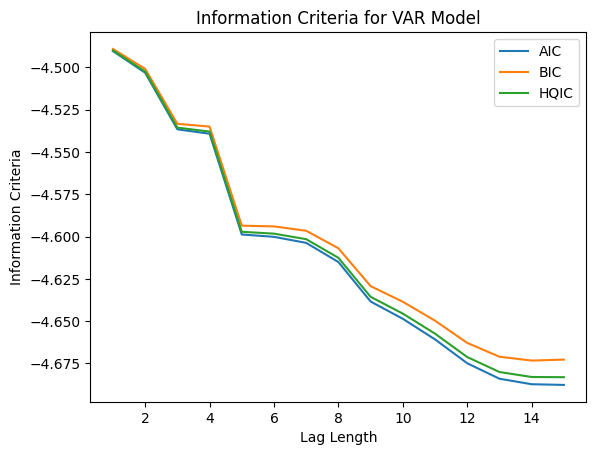

In [ ]:
import matplotlib.pyplot as plt

plt.plot(range(1, max_lag + 1), aic_values, label='AIC')
plt.plot(range(1, max_lag + 1), bic_values, label='BIC')
plt.plot(range(1, max_lag + 1), hqic_values, label='HQIC')

plt.xlabel('Lag Length')
plt.ylabel('Information Criteria')
plt.legend()
plt.title('Information Criteria for VAR Model')
plt.show()


Cosine Similarity:    0.5176
Euclidean Distance:   94.3376
Pearson Correlation:   -0.0388


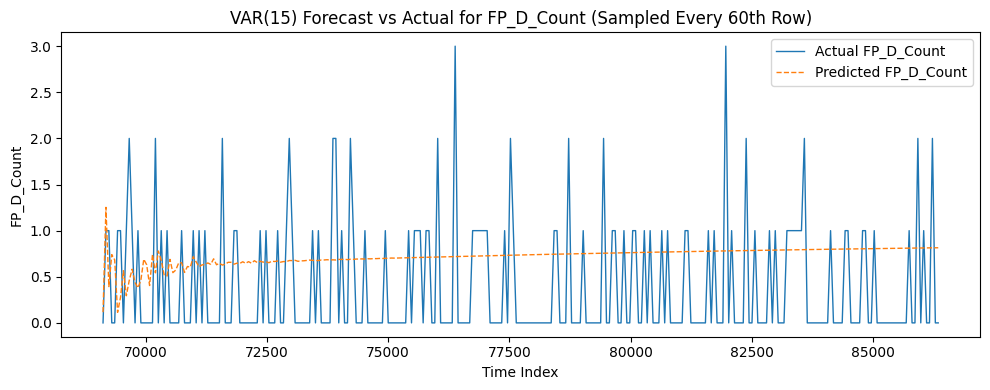

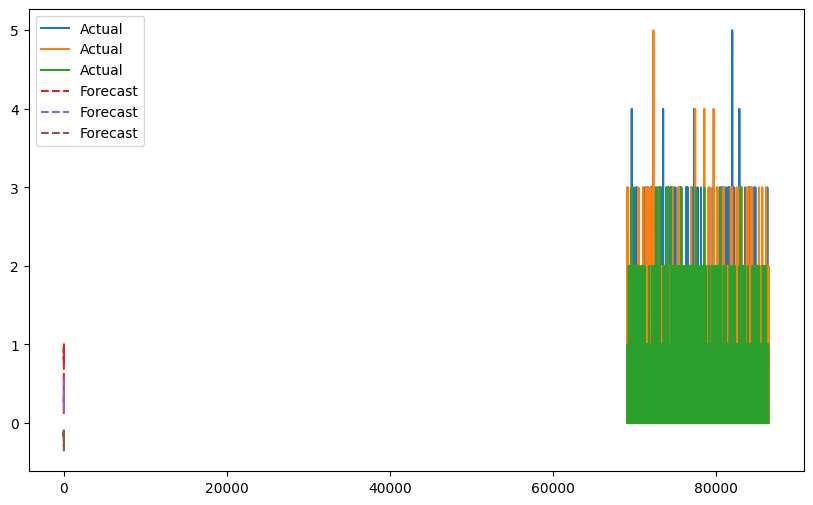

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import euclidean

# 1. Load and preprocess
f = '/content/junction_data_race_course (1).csv'
df = pd.read_csv(f)
df = df.rename(columns={
    'FP_D_Count':'FP_D',
    'FP_A_Count':'FP_A',
    'FP_C_Count':'FP_C'
})
df = df[['FP_D','FP_A','FP_C']].dropna()

# 2. Chronological train/test split (80/20)
n = len(df)
train_df = df.iloc[:int(0.8*n)]
test_df  = df.iloc[int(0.8*n):]

# 3. Fit VAR(p) on training data
p = 1500
model   = VAR(train_df)
var_res = model.fit(p)

# 4. Forecast out-of-sample
init_vals = train_df.values[-p:, :]    # shape (p, 3)
steps     = len(test_df)
fc        = var_res.forecast(y=init_vals, steps=steps)
fc_df     = pd.DataFrame(fc,
                         index=test_df.index,
                         columns=train_df.columns)

# extract predicted vs actual FP_D
y_pred = fc_df['FP_D']
y_test = test_df['FP_D']

# 5. Similarity metrics
cos_sim    = cosine_similarity(
    y_test.values.reshape(1,-1),
    y_pred.values.reshape(1,-1)
)[0,0]
eucl_dist  = euclidean(y_test.values, y_pred.values)
pearson_rc = np.corrcoef(y_test.values, y_pred.values)[0,1]

print(f"Cosine Similarity:    {cos_sim:.4f}")
print(f"Euclidean Distance:   {eucl_dist:.4f}")
print(f"Pearson Correlation:   {pearson_rc:.4f}")

# 6. Plot actual vs predicted (sampling every 60th point)
sampled_y_test = y_test.iloc[::60]  # Sampling every 60th row from y_test
sampled_y_pred = y_pred.iloc[::60]  # Sampling every 60th row from y_pred

plt.figure(figsize=(10,4))
plt.plot(sampled_y_test,  label='Actual FP_D_Count', linewidth=1)
plt.plot(sampled_y_pred,  label='Predicted FP_D_Count', linestyle='--', linewidth=1)
plt.legend()
plt.title('VAR(15) Forecast vs Actual for FP_D_Count (Sampled Every 60th Row)')
plt.xlabel('Time Index')
plt.ylabel('FP_D_Count')
plt.tight_layout()
plt.show()

# Forecast the next n steps ahead
n_steps_ahead = 10  # For example, 10 steps ahead
forecast = var_res.forecast(train_df.values[-var_res.k_ar:], steps=n_steps_ahead)

# Convert the forecasted values into a DataFrame
forecast_df = pd.DataFrame(forecast, columns=train_df.columns)

# Plot the forecast against actual data
plt.figure(figsize=(10, 6))
plt.plot(test_df.index, test_df.values, label="Actual")
plt.plot(forecast_df.index, forecast_df.values, label="Forecast", linestyle="--")
plt.legend()
plt.show()


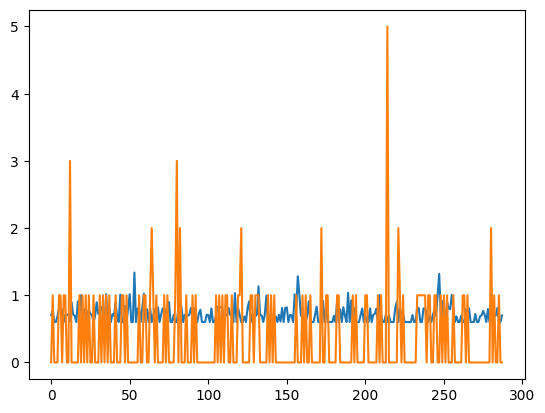

,FP_D
69121,0
69122,0
69123,0
69124,0
69125,0
...,...
86395,0
86396,0
86397,0
86398,1


In [ ]:
import matplotlib.pyplot as plt

plt.plot(list(y_pred[::60]))
plt.plot(list(y_test[::60]))
plt.show()

y_test

In [ ]:
import pandas as pd
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller
import numpy as np

# Assuming df is already your DataFrame, with 'Time' as 0, 1, 2, 3...
f = '/content/junction_data_race_course (1).csv'
df = pd.read_csv(f)
# Drop 'Time' column as it's just a sequence and not a feature for prediction
df = df.drop(columns=['Time'])

# Ensure the dataframe is stationary (ADF test)
def adf_test(series):
    result = adfuller(series)
    return result[1]  # p-value

# Check stationarity for each column (except 'FP_D_Count')
stationary_columns = []
for column in df.columns:
    if column != 'FP_D_Count':
        p_value = adf_test(df[column])
        if p_value < 0.05:
            stationary_columns.append(column)

# Select only the stationary columns, including 'FP_D_Count' as target
stationary_df = df[stationary_columns + ['FP_D_Count']]

# Optionally, apply differencing if needed for non-stationary columns
# stationary_df = stationary_df.diff().dropna()

# Fit the VAR model
model = VAR(stationary_df)
lag_order = model.select_order().aic  # Select optimal lag based on AIC
var_model = model.fit(lag_order)

# Predict 'FP_D_Count' (using all other features as input)
forecast = var_model.forecast(stationary_df.values[-lag_order:], steps=1)  # Forecast next time step

# Forecasted value for 'FP_D_Count'
forecasted_fp_d_count = forecast[0, stationary_df.columns.get_loc('FP_D_Count')]

print(f"Forecasted FP_D_Count: {forecasted_fp_d_count}")


Forecasted FP_D_Count: 0.9332043596963348


In [ ]:
import pandas as pd
from statsmodels.tsa.api import VAR
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

# Assuming df is already your DataFrame, with 'Time' as 0, 1, 2, 3...

# Drop 'Time' column
df = df.drop(columns=['Time'])

# Ensure the dataframe is stationary (ADF test)
def adf_test(series):
    result = adfuller(series)
    return result[1]  # p-value

# Check stationarity for each column (except 'FP_D_Count')
stationary_columns = []
for column in df.columns:
    if column != 'FP_D_Count':
        p_value = adf_test(df[column])
        if p_value < 0.05:
            stationary_columns.append(column)

# Select only the stationary columns, including 'FP_D_Count' as target
stationary_df = df[stationary_columns + ['FP_D_Count']]

# Optionally, apply differencing if needed for non-stationary columns
# stationary_df = stationary_df.diff().dropna()

# Split into training and test data
train_size = int(len(stationary_df) * 0.8)  # 80% for training, 20% for testing
train_data = stationary_df[:train_size]
test_data = stationary_df[train_size:]

# Fit the VAR model on the training data
model = VAR(train_data)
lag_order = model.select_order().aic  # Select optimal lag based on AIC
var_model = model.fit(lag_order)

# Make predictions on the test data
forecast = var_model.forecast(train_data.values[-lag_order:], steps=len(test_data))  # Predict for the test set

# Extract the predicted 'FP_D_Count'
y_pred = forecast[:, stationary_df.columns.get_loc('FP_D_Count')]

# Extract the true 'FP_D_Count' values from the test set
y_test = test_data['FP_D_Count'].values

# Plot y_test vs y_pred
plt.figure(figsize=(10, 6))
plt.plot(range(len(y_test)), y_test, label='True values (y_test)', color='blue')
plt.plot(range(len(y_pred)), y_pred, label='Predicted values (y_pred)', color='red', linestyle='--')
plt.title('True vs Predicted FP_D_Count')
plt.xlabel('Time')
plt.ylabel('FP_D_Count')
plt.legend()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
from sklearn.preprocessing import StandardScaler

# Load your dataset
f = '/content/junction_data_race_course (1).csv'
df = pd.read_csv(f)

# Check for missing values and fill them (you can choose another method for imputation)
df = df.fillna(0)

# Normalize the features
scaler = StandardScaler()
scaled_columns = [
    'FP_A_Count', 'FP_A_QueuePct', 'FP_A_Speed', 'FP_B_Count', 'FP_B_QueuePct', 'FP_B_Speed',
    'FP_C_Count', 'FP_C_QueuePct', 'FP_C_Speed', 'District_Office_Speed', 'Anand_Rao_Jnc_Count',
    'Anand_Rao_Jnc_QueuePct', 'Anand_Rao_Jnc_Speed', 'Race_Course_Jnc_Count', 'Race_Course_Jnc_QueuePct',
    'Race_Course_Jnc_Speed', 'Palace_Road_Jnc_Count', 'Palace_Road_Jnc_QueuePct', 'Palace_Road_Jnc_Speed'
]
df[scaled_columns] = scaler.fit_transform(df[scaled_columns])

# Create lag features for prediction (lag of 1 step)
df['FP_A_Count_lag1'] = df['FP_A_Count'].shift(1)
df['FP_B_Count_lag1'] = df['FP_B_Count'].shift(1)
df = df.dropna()  # Drop rows with missing values after lag shift

# Define states (features) and target (what we want to predict)
states = df[scaled_columns].values
target = df['FP_A_Count'].values  # Change this if you want to predict other features

# Neural Network Model to approximate Q-values
class QNetwork(nn.Module):
    def __init__(self, input_size):
        super(QNetwork, self).__init__()
        self.fc1 = nn.Linear(input_size, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, 1)  # Output a continuous value (predicted FP_A_Count)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

# Hyperparameters
learning_rate = 0.001
gamma = 0.99  # Discount factor
epsilon = 0.1  # Exploration rate
batch_size = 64
memory = deque(maxlen=10000)  # Replay buffer size

# Initialize the Q-network and optimizer
input_size = len(scaled_columns)
q_network = QNetwork(input_size)
optimizer = optim.Adam(q_network.parameters(), lr=learning_rate)
loss_fn = nn.MSELoss()  # Use MSE for continuous value prediction

# Action selection (epsilon-greedy approach)
def select_action(state):
    if np.random.rand() < epsilon:
        return np.random.uniform(-10, 10)  # Exploration: random action
    state_tensor = torch.FloatTensor(state).unsqueeze(0)
    return q_network(state_tensor).item()  # Exploitation: predicted action

# Store experiences in memory (ensure homogeneous structure)
def store_experience(state, action, reward, next_state):
    memory.append((state, action, reward, next_state))

# Train the model using a batch of experiences from memory
def train_model(batch_size=64):
    if len(memory) < batch_size:
        return

    # Sample a batch of experiences from memory
    batch = np.random.choice(len(memory), batch_size, replace=False)  # Get indices, not experiences

    states = torch.FloatTensor([memory[i][0] for i in batch])  # Extract state from memory
    actions = torch.FloatTensor([memory[i][1] for i in batch]).unsqueeze(1)
    rewards = torch.FloatTensor([memory[i][2] for i in batch]).unsqueeze(1)
    next_states = torch.FloatTensor([memory[i][3] for i in batch])

    # Q-value prediction for current states
    q_values = q_network(states)

    # Target Q-value (using Bellman equation)
    next_q_values = q_network(next_states).detach()
    target_q_values = rewards + gamma * next_q_values

    # Compute loss and update Q-network
    loss = loss_fn(q_values, target_q_values)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# Training loop
for episode in range(1000):  # Number of training episodes
    state = df.iloc[0][scaled_columns].values  # Initial state
    done = False
    for t in range(len(df)-1):  # Loop over each timestep
        # Select action (predicted FP_A_Count)
        action = select_action(state)

        # Get the next state and actual reward
        next_state = df.iloc[t+1][scaled_columns].values
        actual = df.iloc[t+1]['FP_A_Count']  # True value of FP_A_Count
        reward = -abs(action - actual)  # Reward is negative error

        # Store experience in memory
        store_experience(state, action, reward, next_state)

        # Train the model
        train_model(batch_size)

        # Update state for the next step
        state = next_state

        if t == len(df) - 2:  # End of episode
            done = True

# Evaluation: Use the trained model to predict the next values of FP_A_Count
# After training, you can evaluate the model's performance using test data or future data
predictions = []
for i in range(len(df)-1):
    state = df.iloc[i][scaled_columns].values
    action = select_action(state)  # Get predicted FP_A_Count
    predictions.append(action)

# You can calculate the prediction error (MSE or MAE) here
true_values = df['FP_A_Count'].iloc[1:].values  # Actual values
predicted_values = np.array(predictions)
mse = np.mean((predicted_values - true_values) ** 2)
print(f'Mean Squared Error: {mse}')


<ipython-input-63-45c7ce75674c>:80: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  states = torch.FloatTensor([memory[i][0] for i in batch])  # Extract state from memory


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error

# Assuming y_test and y_predict are the true and predicted values

# Example: replace y_test and y_predict with the actual values
y_test = df['FP_A_Count'].iloc[1:].values  # True values
y_predict = np.array(predictions)  # Predicted values from the RL model

# Cosine Similarity
cos_sim = cosine_similarity([y_test], [y_predict])[0][0]
print(f'Cosine Similarity: {cos_sim}')

# Pearson Correlation Coefficient
pearson_corr, _ = pearsonr(y_test, y_predict)
print(f'Pearson Correlation Coefficient: {pearson_corr}')

# Mean Squared Error
mse = mean_squared_error(y_test, y_predict)
print(f'Mean Squared Error (MSE): {mse}')

# Plotting true vs predicted values
plt.figure(figsize=(12, 6))

# Plot the true values (y_test) and predicted values (y_predict)
plt.subplot(1, 2, 1)
plt.plot(y_test, label='True Values', color='blue')
plt.plot(y_predict, label='Predicted Values', color='red', linestyle='--')
plt.title('True vs Predicted Values')
plt.xlabel('Time Step')
plt.ylabel('FP_A_Count')
plt.legend()

# Plot the difference (residuals)
plt.subplot(1, 2, 2)
plt.plot(y_test - y_predict, label='Residuals', color='green')
plt.title('Residuals (True - Predicted)')
plt.xlabel('Time Step')
plt.ylabel('Residuals')
plt.legend()

# Show plots
plt.tight_layout()
plt.show()

# Summary of similarity measures
print("\nSimilarity Metrics Summary:")
print(f"Cosine Similarity: {cos_sim:.4f}")
print(f"Pearson Correlation: {pearson_corr:.4f}")
print(f"Mean Squared Error: {mse:.4f}")


In [ ]:
https://www.youtube.com/watch?v=vV12dGe_Fho



https://www.youtube.com/watch?v=c0k-YLQGKjY

RMSE: 0.10
R² Score: 0.94
Cosine Similarity: 0.9910


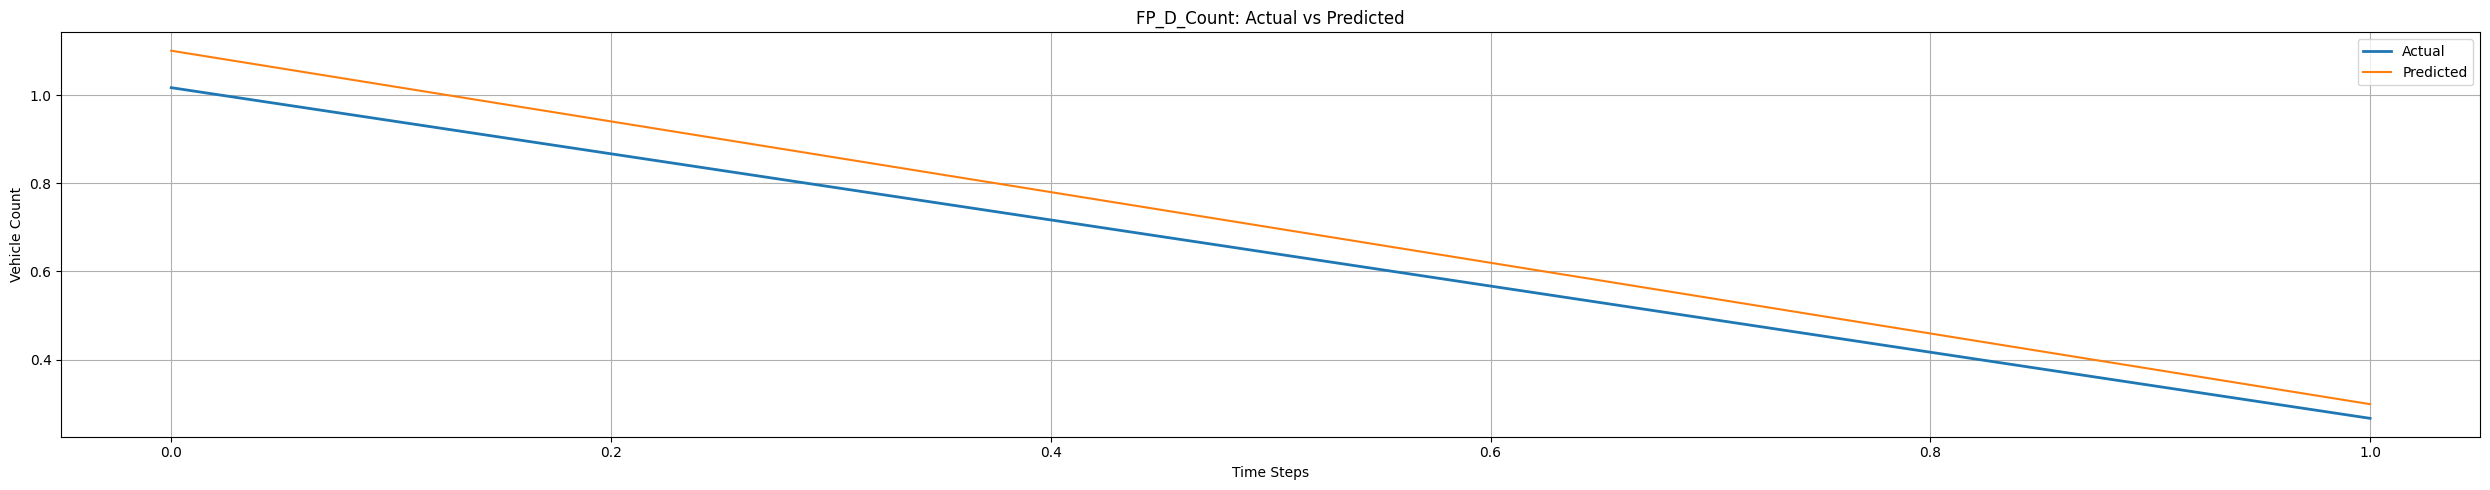

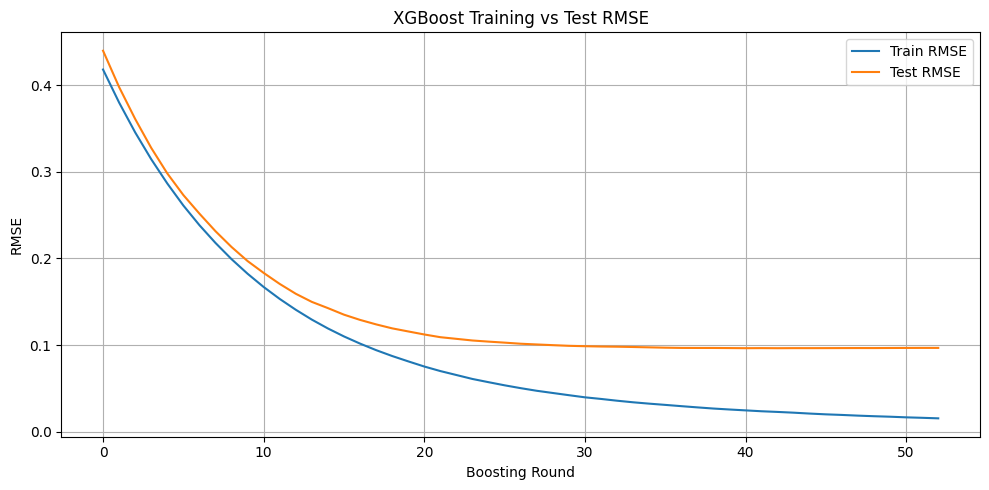

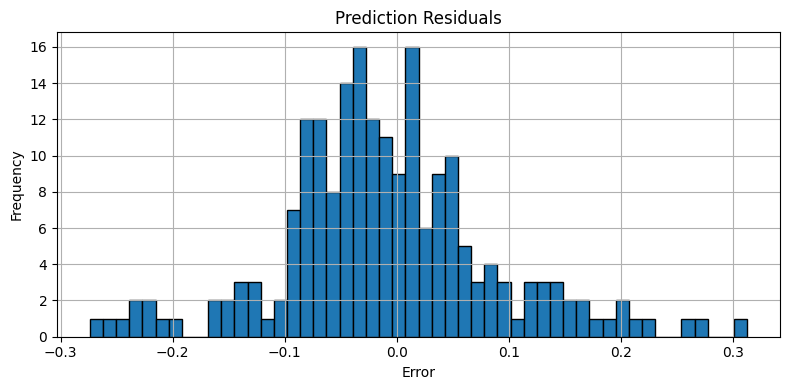

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler

# 1. Load data
f = r'/content/junction_data_race_course (1).csv'
df = pd.read_csv(f)

# 2. Drop Time column if exists
if 'Time' in df.columns:
    df.drop(columns=['Time'], inplace=True)

# 3. Sample by averaging every sample_n rows
sample_n = 120
df= df.groupby(df.index // sample_n).mean().reset_index(drop=True)


# 3. Create lag features for FP_D_Count
n_lags = 50
for lag in range(1, n_lags + 1):
    df[f'FP_D_Count_lag{lag}'] = df['FP_D_Count'].shift(lag)
df.dropna(inplace=True)  # remove rows with NaNs from shifting

# 4. Split into X (features) and y (target)
y = df['FP_D_Count']
X = df.drop(columns=['FP_D_Count'])

# 5. Scale features (helps model convergence and cosine similarity)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 6. Time‑based train/test split (80/20)
split_idx = int(0.7 * len(df))
X_train, X_test = X_scaled[:split_idx], X_scaled[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# 7. Instantiate XGBRegressor with eval_metric & early_stopping_rounds
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.1,
    random_state=42,
    eval_metric='rmse',           # specify metric at construction :contentReference[oaicite:4]{index=4}
    early_stopping_rounds=10      # specify early stopping at construction :contentReference[oaicite:5]{index=5}
)

# 8. Fit with eval_set only
eval_set = [(X_train, y_train), (X_test, y_test)]
model.fit(X_train, y_train, eval_set=eval_set, verbose=False)

# 9. Make predictions
y_pred = model.predict(X_test)

# 10. Evaluate
rmse = root_mean_squared_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)
cos_sim = cosine_similarity([y_test.values], [y_pred])[0][0]

print(f'RMSE: {rmse:.2f}')
print(f'R² Score: {r2:.2f}')
print(f'Cosine Similarity: {cos_sim:.4f}')

# 11. Plot: Actual vs Predicted
plt.figure(figsize=(25,5))
plt.plot(y_test.values[::120], label='Actual', linewidth=2)
plt.plot(y_pred[::120], label='Predicted')
plt.title('FP_D_Count: Actual vs Predicted')
plt.xlabel('Time Steps')
plt.ylabel('Vehicle Count')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 12. Plot: Train vs Test RMSE over boosting rounds
results = model.evals_result()
epochs = len(results['validation_0']['rmse'])
x_axis = range(epochs)

plt.figure(figsize=(10,5))
plt.plot(x_axis, results['validation_0']['rmse'], label='Train RMSE')
plt.plot(x_axis, results['validation_1']['rmse'], label='Test RMSE')
plt.title('XGBoost Training vs Test RMSE')
plt.xlabel('Boosting Round')
plt.ylabel('RMSE')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 13. Plot: Residuals histogram
residuals = y_test - y_pred
plt.figure(figsize=(8,4))
plt.hist(residuals, bins=50, edgecolor='black')
plt.title('Prediction Residuals')
plt.xlabel('Error')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()


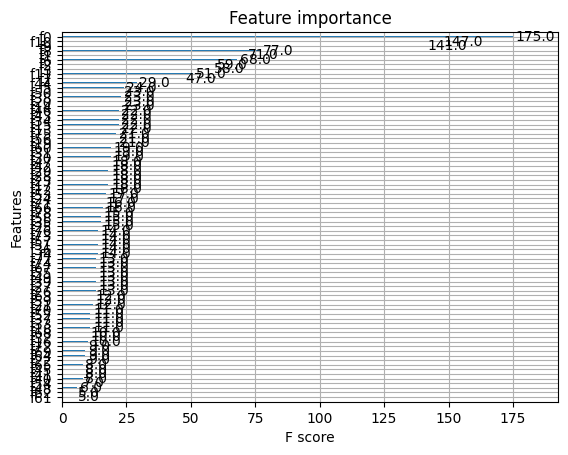

In [ ]:
import xgboost as xgb
import matplotlib.pyplot as plt

# Fit the model

# Plot feature importance (show all features)
xgb.plot_importance(model, importance_type='weight', max_num_features=len(X.columns))
plt.show()


In [ ]:
X

,FP_A_Count,FP_A_QueuePct,FP_A_Speed,FP_B_Count,FP_B_QueuePct,FP_B_Speed,FP_C_Count,FP_C_QueuePct,FP_C_Speed,FP_D_QueuePct,...,FP_D_Count_lag41,FP_D_Count_lag42,FP_D_Count_lag43,FP_D_Count_lag44,FP_D_Count_lag45,FP_D_Count_lag46,FP_D_Count_lag47,FP_D_Count_lag48,FP_D_Count_lag49,FP_D_Count_lag50
50,0.183333,0.072833,4.268333,0.083333,0.016167,0.977167,0.383333,0.060083,5.140500,0.077500,...,0.158333,0.391667,0.441667,0.483333,0.341667,0.600000,0.758333,0.483333,0.308333,0.066667
51,0.283333,0.066917,5.551250,0.325000,0.076500,2.052083,0.283333,0.041083,3.532917,0.054167,...,0.491667,0.158333,0.391667,0.441667,0.483333,0.341667,0.600000,0.758333,0.483333,0.308333
52,0.375000,0.615083,4.877667,0.191667,0.035083,2.460417,0.250000,0.047833,3.469917,0.036000,...,0.483333,0.491667,0.158333,0.391667,0.441667,0.483333,0.341667,0.600000,0.758333,0.483333
53,0.350000,0.143000,4.976250,0.000000,0.002000,0.000000,0.241667,0.032250,4.612667,0.086000,...,0.433333,0.483333,0.491667,0.158333,0.391667,0.441667,0.483333,0.341667,0.600000,0.758333
54,0.225000,0.045833,5.014083,0.000000,0.000000,0.000000,0.133333,0.013250,2.373333,0.078917,...,0.716667,0.433333,0.483333,0.491667,0.158333,0.391667,0.441667,0.483333,0.341667,0.600000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
715,0.316667,0.071750,3.742500,0.150000,0.025583,1.878083,0.133333,0.014500,3.533500,0.039083,...,0.425000,0.400000,0.333333,0.333333,0.350000,0.241667,0.325000,0.466667,0.191667,0.250000
716,0.241667,0.108000,3.740917,0.116667,0.022667,1.413417,0.291667,0.048417,3.559833,0.017000,...,0.391667,0.425000,0.400000,0.333333,0.333333,0.350000,0.241667,0.325000,0.466667,0.191667
717,0.550000,0.410167,5.050333,0.333333,0.062833,4.333167,0.308333,0.049500,2.676000,0.074167,...,0.458333,0.391667,0.425000,0.400000,0.333333,0.333333,0.350000,0.241667,0.325000,0.466667
718,0.291667,0.107667,3.272500,0.100000,0.019500,1.259083,0.291667,0.052333,4.637917,0.080667,...,0.183333,0.458333,0.391667,0.425000,0.400000,0.333333,0.333333,0.350000,0.241667,0.325000


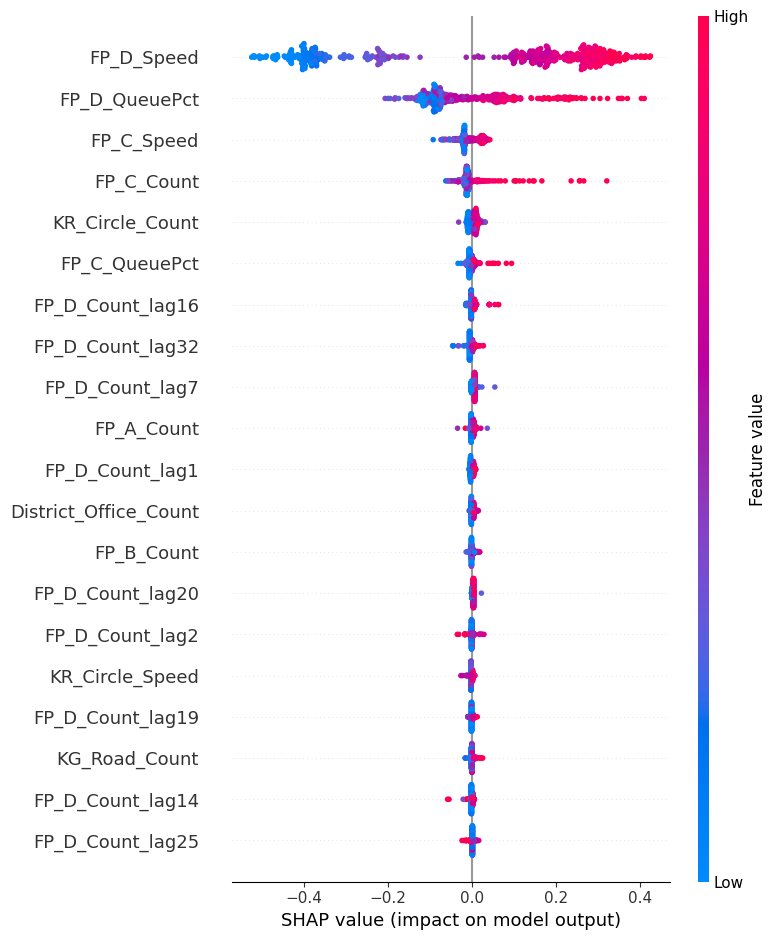

In [ ]:
import shap

# Convert X_train back to a DataFrame after scaling with the column names
X_train_df = pd.DataFrame(X_train, columns=X.columns)

# Create SHAP explainer with the original data and the model
explainer = shap.Explainer(model)

# Get SHAP values
shap_values = explainer(X_train_df)

# SHAP summary plot
shap.summary_plot(shap_values, X_train_df)


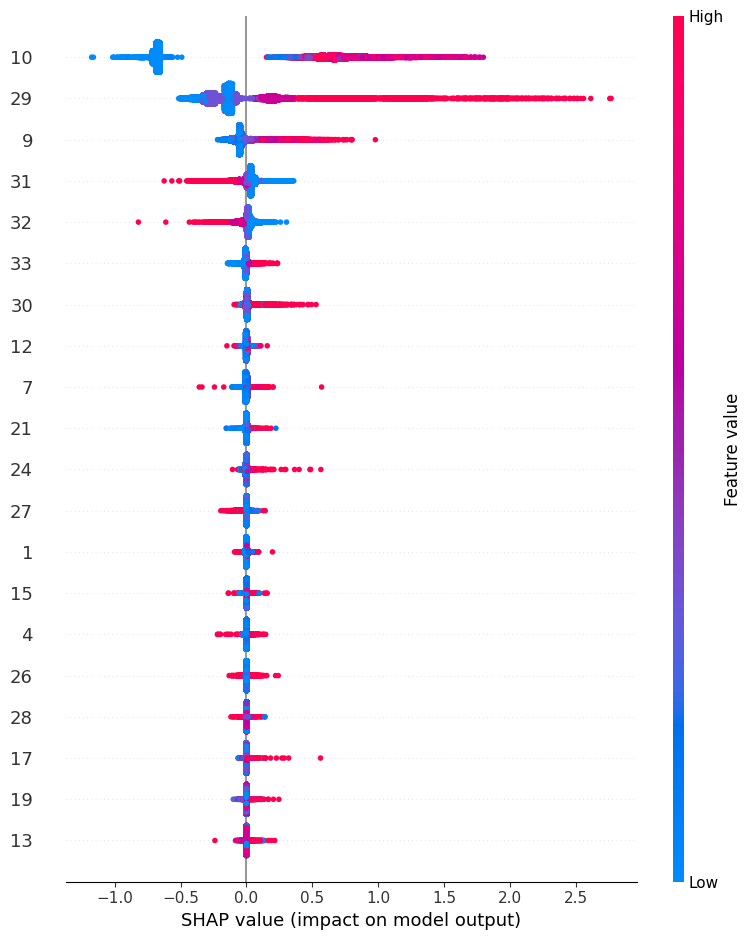

In [ ]:
import shap

# Create a SHAP explainer
explainer = shap.Explainer(model)

X_train = pd.DataFrame(X_train)
shap_values = explainer(X_train)

# SHAP summary plot for all features
shap.summary_plot(shap_values, X_train)


RMSE: 0.10
R² Score: 0.94
Cosine Similarity: 0.9910


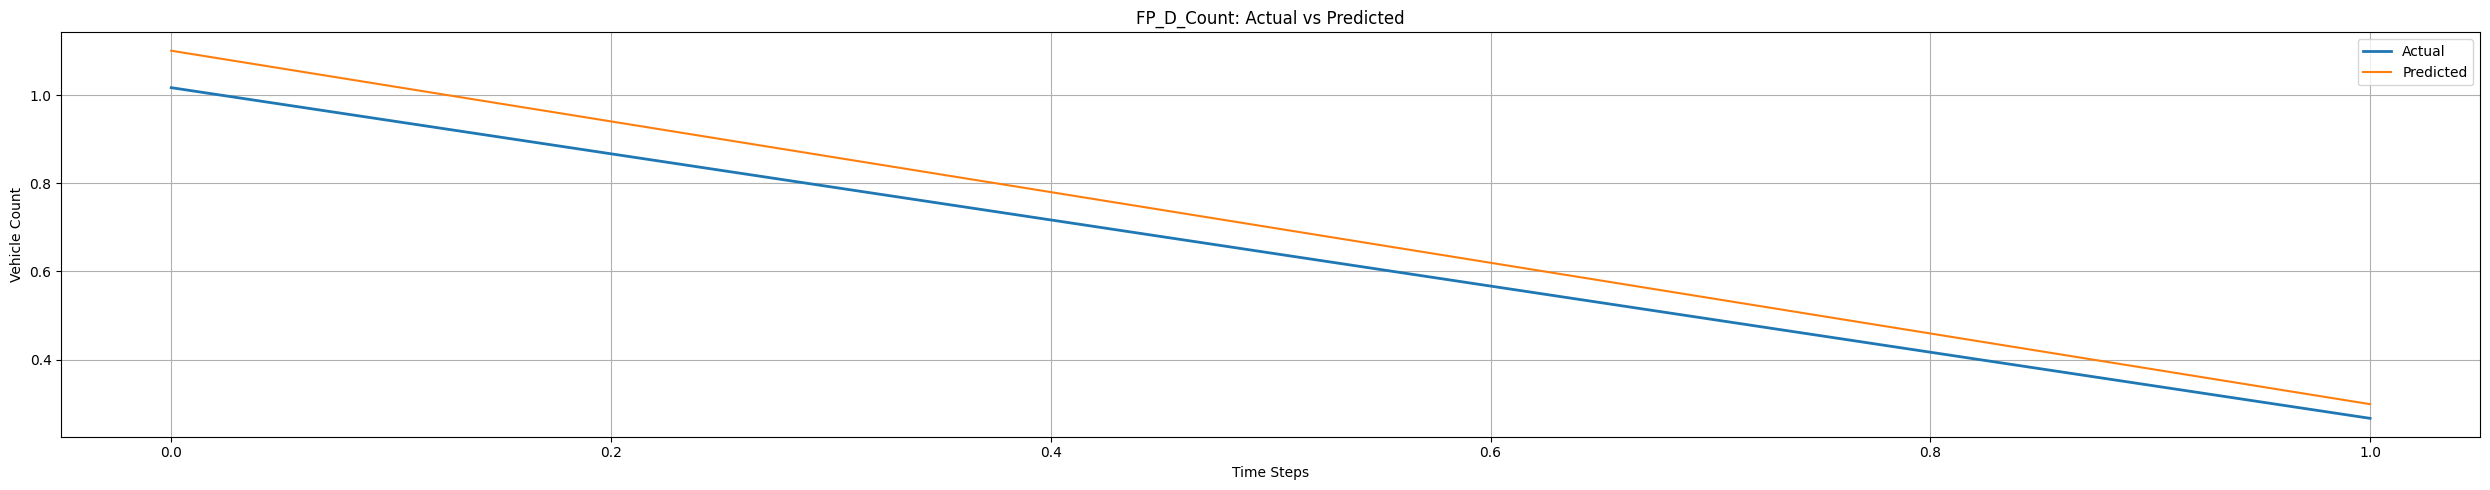

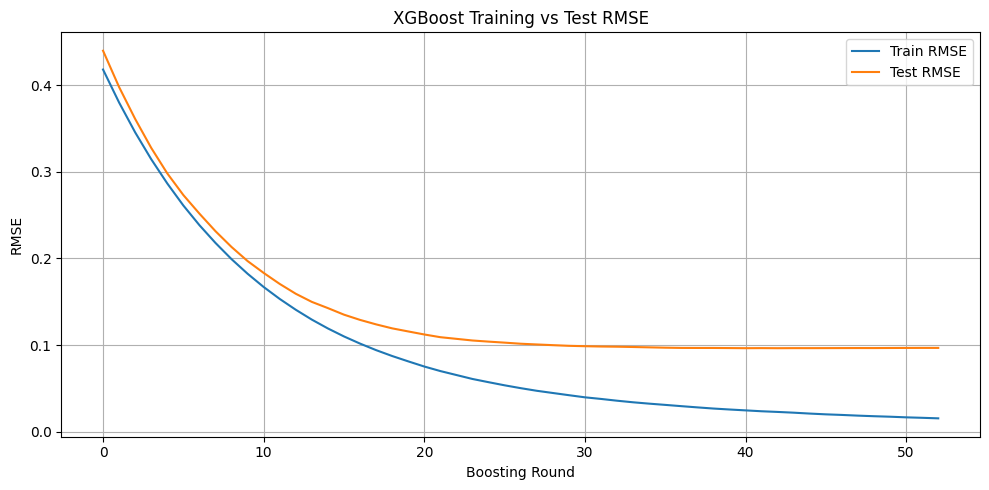

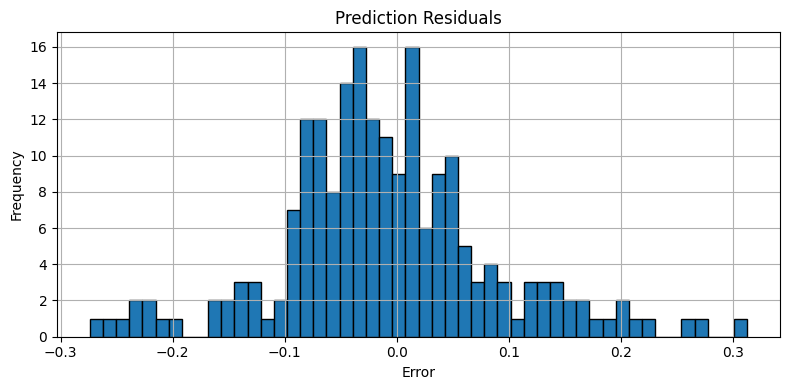

<Figure size 1000x6000 with 0 Axes>

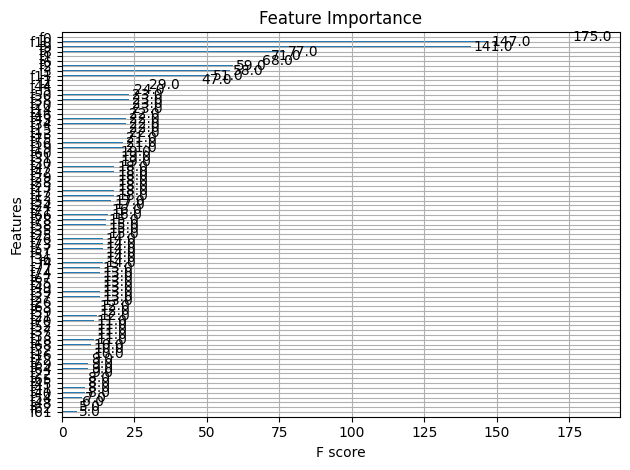

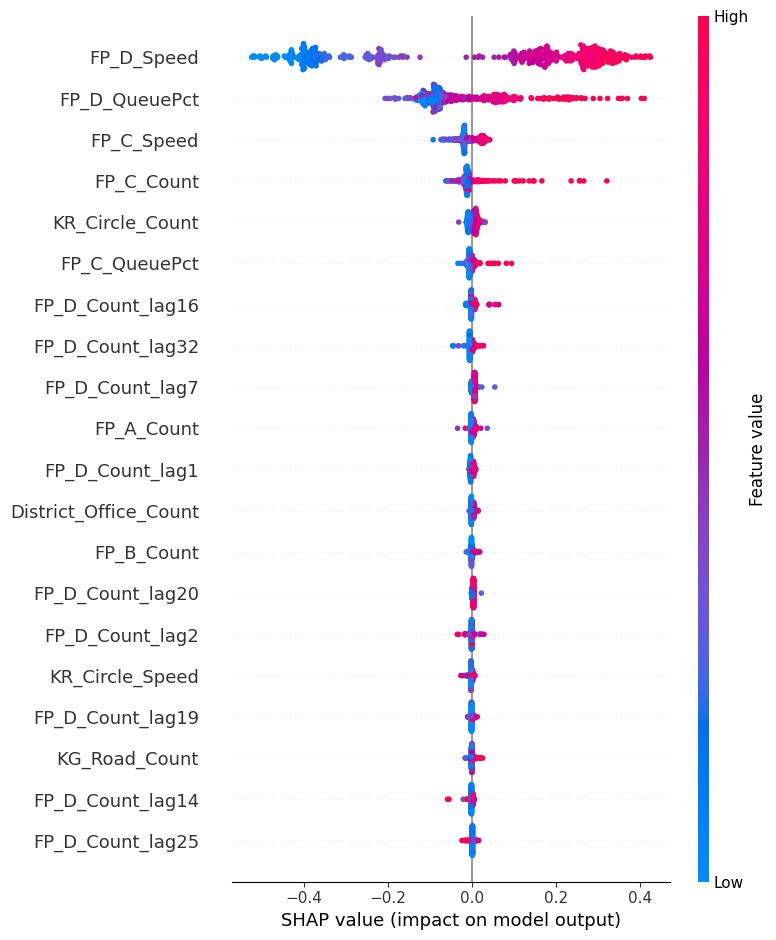

<Figure size 640x480 with 0 Axes>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error as mse, r2_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
import shap
import xgboost as xgb

# 1. Load data
f = r'/content/junction_data_race_course (1).csv'
df = pd.read_csv(f)

# 2. Drop Time column if exists
if 'Time' in df.columns:
    df.drop(columns=['Time'], inplace=True)

# 3. Sample by averaging every sample_n rows
sample_n = 120
df = df.groupby(df.index // sample_n).mean().reset_index(drop=True)

# 4. Create lag features for FP_D_Count
n_lags = 50
for lag in range(1, n_lags + 1):
    df[f'FP_D_Count_lag{lag}'] = df['FP_D_Count'].shift(lag)
df.dropna(inplace=True)  # remove rows with NaNs from shifting

# 5. Split into X (features) and y (target)
y = df['FP_D_Count']
X = df.drop(columns=['FP_D_Count'])

# 6. Scale features (helps model convergence and cosine similarity)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 7. Time-based train/test split (70/30)
split_idx = int(0.7 * len(df))
X_train, X_test = X_scaled[:split_idx], X_scaled[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# 8. Instantiate XGBRegressor with eval_metric & early_stopping_rounds
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.1,
    random_state=42,
    eval_metric='rmse',
    early_stopping_rounds=10
)

# 9. Fit with eval_set only
eval_set = [(X_train, y_train), (X_test, y_test)]
model.fit(X_train, y_train, eval_set=eval_set, verbose=False)

# 10. Make predictions
y_pred = model.predict(X_test)

# 11. Evaluate
rmse = np.sqrt(mse(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
cos_sim = cosine_similarity([y_test.values], [y_pred])[0][0]

# Print Evaluation Metrics
print(f'RMSE: {rmse:.2f}')
print(f'R² Score: {r2:.2f}')
print(f'Cosine Similarity: {cos_sim:.4f}')

# 12. Plot: Actual vs Predicted
plt.figure(figsize=(25,5))
plt.plot(y_test.values[::120], label='Actual', linewidth=2)
plt.plot(y_pred[::120], label='Predicted')
plt.title('FP_D_Count: Actual vs Predicted')
plt.xlabel('Time Steps')
plt.ylabel('Vehicle Count')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('actual_vs_predicted.png')  # Save the plot
plt.show()

# 13. Plot: Train vs Test RMSE over boosting rounds
results = model.evals_result()
epochs = len(results['validation_0']['rmse'])
x_axis = range(epochs)

plt.figure(figsize=(10,5))
plt.plot(x_axis, results['validation_0']['rmse'], label='Train RMSE')
plt.plot(x_axis, results['validation_1']['rmse'], label='Test RMSE')
plt.title('XGBoost Training vs Test RMSE')
plt.xlabel('Boosting Round')
plt.ylabel('RMSE')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('train_vs_test_rmse.png')  # Save the plot
plt.show()

# 14. Plot: Residuals histogram
residuals = y_test - y_pred
plt.figure(figsize=(8,4))
plt.hist(residuals, bins=50, edgecolor='black')
plt.title('Prediction Residuals')
plt.xlabel('Error')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.savefig('residuals_histogram.png')  # Save the plot
plt.show()

# 15. Feature Importance Plot (using XGBoost's plot_importance)
plt.figure(figsize=(10,60))
xgb.plot_importance(model, importance_type='weight', max_num_features=len(X.columns))
plt.title('Feature Importance')
plt.tight_layout()
plt.savefig('feature_importance.png')  # Save the plot
plt.show()

# 16. SHAP Summary Plot
X_train_df = pd.DataFrame(X_train, columns=X.columns)

# Create SHAP explainer with the original data and the model
explainer = shap.Explainer(model)

# Get SHAP values
shap_values = explainer(X_train_df)

# SHAP summary plot
shap.summary_plot(shap_values, X_train_df)
plt.savefig('shap_summary_plot.png')  # Save the plot
plt.show()


In [ ]:
X.columns

Index(['FP_A_Count', 'FP_A_QueuePct', 'FP_A_Speed', 'FP_B_Count',
       'FP_B_QueuePct', 'FP_B_Speed', 'FP_C_Count', 'FP_C_QueuePct',
       'FP_C_Speed', 'FP_D_QueuePct', 'FP_D_Speed', 'KR_Circle_Count',
       'KR_Circle_QueuePct', 'KR_Circle_Speed', 'KG_Road_Count',
       'KG_Road_QueuePct', 'KG_Road_Speed', 'District_Office_Count',
       'District_Office_QueuePct', 'District_Office_Speed',
       'Anand_Rao_Jnc_Count', 'Anand_Rao_Jnc_QueuePct', 'Anand_Rao_Jnc_Speed',
       'Race_Course_Jnc_Count', 'Race_Course_Jnc_QueuePct',
       'Race_Course_Jnc_Speed', 'Palace_Road_Jnc_Count',
       'Palace_Road_Jnc_QueuePct', 'Palace_Road_Jnc_Speed', 'FP_D_Count_lag1',
       'FP_D_Count_lag2', 'FP_D_Count_lag3', 'FP_D_Count_lag4',
       'FP_D_Count_lag5', 'FP_D_Count_lag6', 'FP_D_Count_lag7',
       'FP_D_Count_lag8', 'FP_D_Count_lag9', 'FP_D_Count_lag10',
       'FP_D_Count_lag11', 'FP_D_Count_lag12', 'FP_D_Count_lag13',
       'FP_D_Count_lag14', 'FP_D_Count_lag15', 'FP_D_Count_lag16'

In [ ]:
X

,FP_A_Count,FP_A_QueuePct,FP_A_Speed,FP_B_Count,FP_B_QueuePct,FP_B_Speed,FP_C_Count,FP_C_QueuePct,FP_C_Speed,FP_D_QueuePct,...,FP_D_Count_lag41,FP_D_Count_lag42,FP_D_Count_lag43,FP_D_Count_lag44,FP_D_Count_lag45,FP_D_Count_lag46,FP_D_Count_lag47,FP_D_Count_lag48,FP_D_Count_lag49,FP_D_Count_lag50
50,0.183333,0.072833,4.268333,0.083333,0.016167,0.977167,0.383333,0.060083,5.140500,0.077500,...,0.158333,0.391667,0.441667,0.483333,0.341667,0.600000,0.758333,0.483333,0.308333,0.066667
51,0.283333,0.066917,5.551250,0.325000,0.076500,2.052083,0.283333,0.041083,3.532917,0.054167,...,0.491667,0.158333,0.391667,0.441667,0.483333,0.341667,0.600000,0.758333,0.483333,0.308333
52,0.375000,0.615083,4.877667,0.191667,0.035083,2.460417,0.250000,0.047833,3.469917,0.036000,...,0.483333,0.491667,0.158333,0.391667,0.441667,0.483333,0.341667,0.600000,0.758333,0.483333
53,0.350000,0.143000,4.976250,0.000000,0.002000,0.000000,0.241667,0.032250,4.612667,0.086000,...,0.433333,0.483333,0.491667,0.158333,0.391667,0.441667,0.483333,0.341667,0.600000,0.758333
54,0.225000,0.045833,5.014083,0.000000,0.000000,0.000000,0.133333,0.013250,2.373333,0.078917,...,0.716667,0.433333,0.483333,0.491667,0.158333,0.391667,0.441667,0.483333,0.341667,0.600000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
715,0.316667,0.071750,3.742500,0.150000,0.025583,1.878083,0.133333,0.014500,3.533500,0.039083,...,0.425000,0.400000,0.333333,0.333333,0.350000,0.241667,0.325000,0.466667,0.191667,0.250000
716,0.241667,0.108000,3.740917,0.116667,0.022667,1.413417,0.291667,0.048417,3.559833,0.017000,...,0.391667,0.425000,0.400000,0.333333,0.333333,0.350000,0.241667,0.325000,0.466667,0.191667
717,0.550000,0.410167,5.050333,0.333333,0.062833,4.333167,0.308333,0.049500,2.676000,0.074167,...,0.458333,0.391667,0.425000,0.400000,0.333333,0.333333,0.350000,0.241667,0.325000,0.466667
718,0.291667,0.107667,3.272500,0.100000,0.019500,1.259083,0.291667,0.052333,4.637917,0.080667,...,0.183333,0.458333,0.391667,0.425000,0.400000,0.333333,0.333333,0.350000,0.241667,0.325000
